<a href="https://colab.research.google.com/github/tharindidinuja-lang/customer-churn-analysis/blob/main/task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving Telco_Customer_Churn_Dataset .csv to Telco_Customer_Churn_Dataset .csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#nevigate to your file
import pandas as pd
df= pd.read_csv('Telco_Customer_Churn_Dataset .csv')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
# if you need method 1(quick upload), get the filename
# the uploaded filrs dictionary contains files filename as key

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
# basic information abovt your dataset
print("Dataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 tows:")
print(df.head())
print("\nBasic statistics:")
print(df.describe())


Dataset shape: (7043, 21)

Column names: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

First 5 tows:
   cu

Empty DataFrame
Columns: [Missing Count, Missing Precentage]
Index: []


<function matplotlib.pyplot.show(close=None, block=None)>

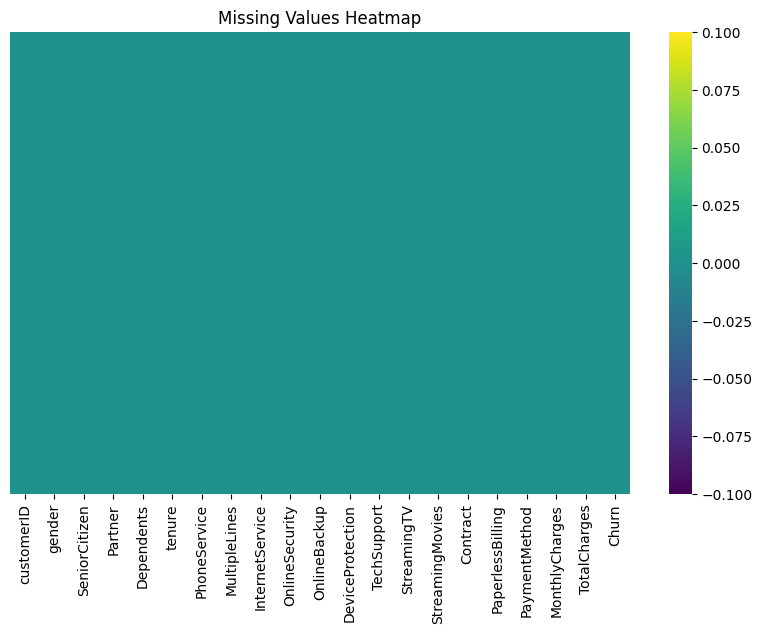

In [ ]:
# count missing valus in each colum

missing_count = df.isnull().sum()
missing_percentage = (df.isnull().sum()/ len(df)*100)

# create a missing data summary
missing_df = pd.DataFrame({'Missing Count' : missing_count,
                           'Missing Precentage':missing_percentage
                           })
print(missing_df[missing_df['Missing Count'] > 0])

#visualize missing data

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(),yticklabels=False, cbar=True, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show

In [ ]:
try:
    # drop rows with any missing values
    df_clean = df.dropna()

    # drop rows where speciic columns have missing valus
    df_clean = df.dropna(subset=['important_column1' , 'important_column2'])

    # drop columns with too many missing values(ex: >50% missing)
    threshold = len(df)*0.5
    df_clean = df. dropna(axis = 1, thresh = threshold)
except NameError:
    print("Error: DataFrame 'df' is not defined. Please ensure the cells defining 'df' (e.g., cell 'hmw68D1j6y_b') have been executed before running this cell.")

Error: DataFrame 'df' is not defined. Please ensure the cells defining 'df' (e.g., cell 'hmw68D1j6y_b') have been executed before running this cell.


In [ ]:
import pandas as pd
import numpy as np
from google.colab import files # Added for completeness if files functions are used

# Ensure filename is defined from the uploaded files or fallback to known filename
try:
    filename = list(uploaded.keys())[0]
except NameError:
    # If 'uploaded' is not defined, we use the known filename from previous uploads
    # This assumes the file is still present in the Colab environment.
    filename = 'Telco_Customer_Churn_Dataset (1).csv' # Corrected filename based on upload output
    print("Warning: 'uploaded' variable not found. Using default filename 'Telco_Customer_Churn_Dataset (1).csv'.")

df = pd.read_csv(filename)

# fill missing values
# make a copy to preserve original
df_clean = df.copy()

#for numaric columns:fill with mean/median
numaric_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in numaric_cols:
  if df_clean[col].isnull().any():
    df_clean[col].fillna(df_clean[col].mean(), inplace= True);

#for catagorical values:fill with frequent valu
categorical_clos  = df_clean.select_dtypes(include=['object']).columns
for col in categorical_clos:
  if df_clean[col].isnull().any():
    df_clean[col].fillna(df_clean[col].mode()[0], inplace= True)

#alternatives: fill with a special value
# df_clean['colunm_name'].fillna('Unknown', inplace= True) # These are placeholder examples and can be removed or commented out
# df_clean['numeric_column'].fillna(0, inplace= True) # These are placeholder examples and can be removed or commented out

In [ ]:
import pandas as pd

#identify catagarical columns
# find object type columns


# load dataset
# Use the 'filename' variable which holds the correctly uploaded file name
df = pd.read_csv(filename)

# clean dataset
df_clean = df.dropna()

# identify categorical columns
category_columns = df_clean.select_dtypes(include=['object']).columns
print("Categorical columns:", category_columns.tolist())

# check unique values in each categorical column
for col in category_columns:
    print(f"\n{col}: {df_clean[col].nunique()} unique values")
    print(df_clean[col].value_counts().head())

Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']

customerID: 7043 unique values
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
Name: count, dtype: int64

gender: 2 unique values
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner: 2 unique values
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents: 2 unique values
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService: 2 unique values
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines: 3 unique values
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService: 3 unique values
InternetServic

In [ ]:
import os
print(os.listdir())

['.config', 'drive', 'Telco_Customer_Churn_Dataset .csv', 'sample_data']


In [ ]:
df = pd.read_csv("Telco_Customer_Churn_Dataset .csv")

FileNotFoundError: [Errno 2] No such file or directory: 'Telco_Customer_Churn_Dataset .csv'

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Telco_Customer_Churn_Dataset .csv to Telco_Customer_Churn_Dataset .csv


In [ ]:
import pandas as pd
import numpy as np
from google.colab import files # Added for completeness if files functions are used

# Ensure filename is defined from the uploaded files or fallback to known filename
try:
    filename = list(uploaded.keys())[0]
except NameError:
    # If 'uploaded' is not defined, we use the known filename from previous uploads
    # This assumes the file is still present in the Colab environment.
    filename = 'Telco_Customer_Churn_Dataset (1).csv' # Corrected filename based on upload output
    print("Warning: 'uploaded' variable not found. Using default filename 'Telco_Customer_Churn_Dataset (1).csv'.")

df = pd.read_csv(filename)

# fill missing values
# make a copy to preserve original
df_clean = df.copy()

#for numaric columns:fill with mean/median
numaric_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in numaric_cols:
  if df_clean[col].isnull().any():
    df_clean[col].fillna(df_clean[col].mean(), inplace= True);

#for catagorical values:fill with frequent valu
categorical_clos  = df_clean.select_dtypes(include=['object']).columns
for col in categorical_clos:
  if df_clean[col].isnull().any():
    df_clean[col].fillna(df_clean[col].mode()[0], inplace= True)

In [ ]:
import pandas as pd

#identify catagarical columns
# find object type columns


# load dataset
df = pd.read_csv("Telco_Customer_Churn_Dataset .csv")

# clean dataset
df_clean = df.dropna()

# identify categorical columns
category_columns = df_clean.select_dtypes(include=['object']).columns
print("Categorical columns:", category_columns.tolist())

# check unique values in each categorical column
for col in category_columns:
    print(f"\n{col}: {df_clean[col].nunique()} unique values")
    print(df_clean[col].value_counts().head())

Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']

customerID: 7043 unique values
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
Name: count, dtype: int64

gender: 2 unique values
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner: 2 unique values
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents: 2 unique values
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService: 2 unique values
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines: 3 unique values
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService: 3 unique values
InternetServic

In [ ]:
import pandas as pd
# load dataset
df = pd.read_csv("Telco_Customer_Churn_Dataset .csv")
# clean dataset
df_clean = df.dropna()
# encode catagorical column
df_encoded = pd.get_dummies(df_clean)

# check for any remaining missing values
print("Remaining missing values:", df_encoded.isnull().sum().sum())

# verify data types
print("\nData types after encoding:")
print(df_encoded.dtypes.value_counts())

# summary statistics
print("\nDataset info:")
print(f"Rows: {df_encoded.shape[0]}, Columns: {df_encoded.shape[1]}")


Remaining missing values: 0

Data types after encoding:
bool       13617
int64          2
float64        1
Name: count, dtype: int64

Dataset info:
Rows: 7043, Columns: 13620


In [ ]:
import pandas as pd
import numpy as np
from google.colab import files
# Added for completeness if files functions are used

print('setup complete!')

#upload file
print ("\n Telco_Customer_Churn_Dataset .csv")
uploaded = files.upload()
filename =  list(uploaded.keys())[0]
print(f"loaded:{filename}")

#read file
df = pd.read_csv(filename)
print(f"\n Dataset Info:")
print(f"  Rows: {df.shape[0]}") # Corrected escape sequence
print(f"  Columns: {df.shape[1]}") # Corrected escape sequence
print(f"\n First 3 rows:")
print(df.head(3))

#understand data types
print("\n" + "=" * 50)
print("Data type analysis")
print("=" * 50)
print(df.dtypes.value_counts())
print("\nColumn details:")
for col in df.columns:
  unique_values = df[col].unique()[:5]# first 5 unique value
  print(f"{col}:{df[col].dtype}-sample value:{unique_values}") # Corrected indentation

#Handle the FALSE/TRUE columns (convert to 0/1)
print("\n" + "="*50 )
print("converting false/true to 0/1")
print("="*50)

#find boolean column(true/fales)
bool_columns =[]
for col in df.columns:
  if df[col].dtype == 'bool' or set(df[col].unique()).issubset({True, False,'True','False', 'TRUE', 'FALSE'}):
    bool_columns.append(col)
  print(f"Found {len(bool_columns)} boolean columns:")


# convert them to 0 and 1

for col in bool_columns:
  # convert to string first to handle different formats
  df[col] = df[col].astype(str).str.upper().map({'TRUE':1, 'FALSE':0}) # Corrected 'FALSE:'0
  print(f"converted: {col}") # Corrected f-string syntax

#check for missing values
print("\n" + "="*50)
print("missing value check")
print("="*50)

missing_data = pd.DataFrame({
    'column': df.columns,
    'missing count': df.isnull().sum().values,
    'missing_percentage':(df.isnull().sum()/len(df)*100).round(2)
})

missing_with_values=missing_data[missing_data['missing count'] > 0]
if len(missing_with_values) > 0: # Added colon
    print("found missing values:")
    print(missing_with_values)

#fill missing values
print("\n Filling missing values....")

#for numarin columns
numeric_cols=df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
  if df[col].isnull().any():
    df[col].fillna(df[col].median(),inplace=True)
    print(f"Filled numaric:{col}")

# for catagorical
categorical_cols=df.select_dtypes(include=['object']).columns
for col in categorical_cols:
  if df[col].isnull().any():
    df[col].fillna(df[col].mode()[0],inplace=True)
    print(f"Filled catagorical:{col}")
  else:
    print("no missing values") # This else block should be outside the loop if it's meant to summarize the whole process after the loop

#final data check
print("\n" + "="*50)
print("final data check")
print("="*50)
print(f"final shape:{df.shape}")
print("\nData type after conversion:")
print(df.dtypes.value_counts())
print(f"\nSample of converted boolean column(now 0/1):") # Corrected 'Samplt'
for col in bool_columns:
  print(f"{col}:{df[col].unique()}")

#save as clean excel file
# Use os.path.splitext for more robust extension handling
import os
base_filename = os.path.splitext(filename)[0].strip() # Remove extension and leading/trailing spaces
output_filename='cleaned_'+base_filename+'.xlsx'

with pd.ExcelWriter(output_filename, engine='openpyxl') as writer: # Corrected typo and indentation
  #main clean data
  df.to_excel(writer, sheet_name='clean_data', index=False)
  # summary
  summary_data={
  'Metric':['Total Rows', 'Total Columns','Boolean Columns converted'],
  'Values':[df.shape[0],df.shape[1],len(bool_columns)]
    } # Corrected variable name from summary_dat
  pd.DataFrame(summary_data).to_excel(writer, sheet_name='summary', index=False)

  #data type sheet
  dtypes_df= pd.DataFrame({ # Corrected typo from 'pf'
      'Column':df.columns,
      'Data type': df.dtypes.values,
      'Unique value':[df[col].nunique()for col in df.columns]
  })

  dtypes_df.to_excel(writer, sheet_name='Column Info', index=False) # Corrected sheet name 'Infor'

print(f"\n save as:{output_filename}")

#download
files.download(output_filename)
print("\n Done! Your Excel file is downloaded with 0/1 instead of FALSE/TRUE!")


setup complete!

 Telco_Customer_Churn_Dataset .csv


Saving Telco_Customer_Churn_Dataset .csv to Telco_Customer_Churn_Dataset  (1).csv
loaded:Telco_Customer_Churn_Dataset  (1).csv

 Dataset Info:
  Rows: 7043
  Columns: 21

 First 3 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0          No          No              No  Month-to-month              Yes   
1          No          No       

/tmp/ipykernel_154/2131619751.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(),inplace=True)



 save as:cleaned_Telco_Customer_Churn_Dataset  (1).xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 Done! Your Excel file is downloaded with 0/1 instead of FALSE/TRUE!
